![Built with AI](https://img.shields.io/badge/Built%20with-AI-blue.svg)

# Laboratorio — Almacenamiento en disco y desempeño de I/O

Este notebook es la parte práctica del laboratorio de acceso a disco. Permite medir y comparar:

- acceso secuencial vs acceso aleatorio
- distintos tamaños de bloque
- resultados empíricos vs estimaciones teóricas

---

## Cómo usar este notebook

En este laboratorio encontrará tres tipos de secciones:

- **Ejecute esta celda:** contiene código listo para usar.
- **Analice:** debe interpretar los resultados obtenidos.
- **Conclusión:** debe redactar una respuesta breve con sus hallazgos.

> **Recomendación:** antes de ejecutar todo, revise la sección de
> **configuración** para ajustar el tamaño del archivo y el número de
> lecturas aleatorias según la capacidad de su equipo.

> **Recursos de apoyo:** las figuras de referencia para este laboratorio
> se encuentran en el `README.md` de la guía:
> - **fig1** — Jerarquía de memoria y latencias de referencia
> - **fig2** — Modelo de costo I/O y sus componentes
> - **fig3** — Comparación visual: acceso secuencial vs aleatorio
>
> Se recomienda tenerlas a mano mientras ejecuta el notebook.

## 0. Verificación del entorno

Ejecute la siguiente celda antes de continuar. Confirmará que todas
las librerías necesarias están disponibles en su entorno.

Si alguna librería aparece marcada con ✗, instálela con:

```bash
pip install nombre_libreria
```

En Google Colab todas las librerías ya están disponibles.

In [1]:
import sys
import importlib

librerias_requeridas = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
}

print(f'Python: {sys.version}')
print('-' * 40)

todo_ok = True
for nombre, modulo in librerias_requeridas.items():
    try:
        lib = importlib.import_module(modulo)
        version = getattr(lib, '__version__', 'versión no disponible')
        print(f'✓ {nombre} {version}')
    except ImportError:
        print(f'✗ {nombre} — NO encontrada. Instale con: pip install {nombre}')
        todo_ok = False

print('-' * 40)
if todo_ok:
    print('Entorno listo. Puede continuar con el laboratorio.')
else:
    print('Corrija las dependencias faltantes antes de continuar.')

Python: 3.13.2 (tags/v3.13.2:4f8bb39, Feb  4 2025, 15:23:48) [MSC v.1942 64 bit (AMD64)]
----------------------------------------
✓ numpy 2.2.4
✓ pandas 3.0.1
✓ matplotlib 3.10.1
----------------------------------------
Entorno listo. Puede continuar con el laboratorio.


## 1. Objetivos del notebook

Al finalizar esta práctica debería poder:

1. Entender cómo afecta el patrón de acceso al rendimiento.
2. Medir tiempos de lectura secuencial y aleatoria.
3. Calcular throughput empírico.
4. Comparar mediciones con un modelo teórico simple de I/O.
5. Visualizar los resultados con gráficas automáticas.

In [2]:
import os
import time
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Entorno listo.')

Entorno listo.


## 2. Recordatorio teórico

Antes de iniciar las mediciones, repase los conceptos clave que
usará a lo largo del experimento.

### Jerarquía de memoria y costo de acceso

Los dispositivos de almacenamiento tienen latencias muy distintas.
Un acceso a RAM toma nanosegundos; un acceso a disco puede tomar
milisegundos — una diferencia de hasta un millón de veces. Por eso
los sistemas están diseñados para minimizar los accesos a disco.

### Bloques de I/O

El disco no lee bytes individuales — lee **bloques completos**.
Incluso si un programa solicita 1 byte, el sistema transfiere todo
el bloque (típicamente 4 KB en sistemas operativos, 4–16 KB en
motores de bases de datos).

### Patrones de acceso

- **Secuencial:** los bloques se leen uno tras otro en posiciones
  contiguas. El número de accesos físicos al disco es mínimo (M ≈ 1).
- **Aleatorio:** cada bloque está en una posición distinta del disco.
  Cada acceso requiere posicionamiento independiente, por lo que M
  puede ser muy grande.

### Modelo de costo I/O

$$TotalTime = AccessLatency \times M + \frac{DataSize}{ScanThroughput}$$

- **AccessLatency:** tiempo para acceder al inicio de un bloque.
- **M:** número de accesos no contiguos al disco.
- **DataSize:** volumen total de datos a leer.
- **ScanThroughput:** velocidad de lectura sostenida del dispositivo.

> **Conexión con clase:** en las diapositivas se estudió el modelo
> detallado del HDD: $T_{access} = T_{seek} + T_{rotation} + T_{transfer}$.
> En este laboratorio, $AccessLatency$ agrupa $T_{seek}$ y $T_{rotation}$
> en un único valor promedio. Esta simplificación permite comparar
> tecnologías distintas (HDD, SSD, NVMe) con la misma fórmula.

## Punto de control 1 — Revisión conceptual

Antes de continuar, responda brevemente:

1. ¿Qué representa la latencia en este laboratorio?
2. ¿Qué representa el throughput?
3. ¿Por qué en acceso secuencial normalmente se asume que $M \approx 1$?
4. ¿Por qué en acceso aleatorio $M$ tiende a ser mayor?

> **Criterio mínimo:** cada respuesta debe tener al menos una oración
> propia. No copie definiciones — explíquelo con sus palabras.

### Respuestas

**- Respuesta 1:** La latencia en este laboratorio representa el tiempo que tarda el sistema en iniciar el acceso a un bloque de datos en el dispositivo de almacenamiento.
**- Respuesta 2:** El throughput representa la velocidad a la que se pueden transferir los datos una vez que ya comenzó la lectura. Es decir, mide qué tan rápido se leen grandes cantidades de información de forma continua.
**- Respuesta 3:** Porque en el acceso secuencial los datos están organizados de manera continua, entonces el disco solo necesita posicionarse una vez y luego puede leer todo seguido sin interrupciones. Por eso el número de accesos no contiguos es mínimo.
**- Respuesta 4:** Porque en el acceso aleatorio los datos están dispersos en diferentes partes del disco, así que el sistema debe reposicionarse muchas veces para leer cada bloque. Esto aumenta la cantidad de accesos no contiguos.

## 3. Configuración del experimento

Puede ajustar estos parámetros según el tiempo disponible y la capacidad del entorno.

In [3]:
# ==============================
# CONFIGURACIÓN GENERAL
# ==============================

DATA_DIR = Path('io_lab_data')
DATA_DIR.mkdir(exist_ok=True)

FILE_PATH = DATA_DIR / 'dataset.bin'

# Tamaño del archivo a generar.
# En Colab se recomienda entre 128 y 512 MB.
FILE_SIZE_MB = 256

# Tamaños de bloque a comparar
BLOCK_SIZES = [4 * 1024, 16 * 1024, 64 * 1024, 256 * 1024]

# Número de lecturas aleatorias por tamaño de bloque
RANDOM_READS = 4000

# Semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Archivo:', FILE_PATH)
print('Tamaño objetivo (MB):', FILE_SIZE_MB)
print('Bloques a probar (bytes):', BLOCK_SIZES)
print('Número de lecturas aleatorias:', RANDOM_READS)

Archivo: io_lab_data\dataset.bin
Tamaño objetivo (MB): 256
Bloques a probar (bytes): [4096, 16384, 65536, 262144]
Número de lecturas aleatorias: 4000


## Punto de control 2 — Reflexión sobre la configuración

Observe los parámetros impresos por la celda anterior y responda:

1. **Tamaño del archivo:** ¿Es suficiente para superar la caché RAM de
   su equipo? Compare con los valores de RAM registrados en la Etapa 1
   de la guía.

3. **Tamaño de bloque:** Los tamaños evaluados (4 KB, 16 KB, 64 KB,
   256 KB) corresponden a tamaños típicos de páginas en sistemas
   operativos y motores de bases de datos. ¿Cuál esperaría que tuviera
   mejor rendimiento en acceso aleatorio y por qué?

5. **Entorno de ejecución:** ¿Está ejecutando en local o en Google Colab?
   Recuerde que en Colab los tiempos medidos corresponden al hardware de
   Google, no al suyo.

### Respuestas

**- Respuesta 1:** El tamaño del archivo es de 256 MB, mientras que la memoria RAM del equipo es de 8 GB. Esto significa que el archivo es mucho más pequeño que la RAM disponible, por lo que no es suficiente para superar la caché del sistema. En consecuencia, es probable que muchos accesos se realicen desde memoria y no directamente desde el disco.
**- Respuesta 2:** En acceso aleatorio, esperaría mejor rendimiento con bloques más grandes como 64 KB o 256 KB, porque cada acceso al disco tiene un costo alto de latencia. Al leer bloques más grandes, se aprovecha mejor cada acceso, ya que se obtiene más información en una sola operación, reduciendo el impacto de la latencia.
**- Respuesta 3:** El laboratorio se está ejecutando en entorno local, por lo que los tiempos medidos corresponden al hardware de mi propio equipo y reflejan directamente el rendimiento de mi sistema de almacenamiento.

### Reinicio del experimento

Si desea cambiar el tamaño del archivo de prueba y repetir el
experimento desde cero, ejecute la siguiente celda antes de continuar.
Esto eliminará el archivo generado anteriormente y forzará su
recreación con los nuevos parámetros.

> **Nota:** en condiciones normales no es necesario ejecutar esta
> celda. Omítala si es la primera vez que corre el notebook.

In [ ]:
# ==============================
# REINICIO DEL EXPERIMENTO
# (opcional — solo si cambió FILE_SIZE_MB)
# ==============================

import shutil

RESET = False  # Cambie a True para eliminar el archivo de prueba

if RESET:
    if DATA_DIR.exists():
        shutil.rmtree(DATA_DIR)
        DATA_DIR.mkdir(exist_ok=True)
        print(f'Carpeta {DATA_DIR} eliminada. El archivo se recreará en la siguiente sección.')
    else:
        print('No hay archivos previos que eliminar.')
else:
    print('RESET = False. No se eliminó ningún archivo.')
    print('Cambie RESET = True si desea repetir el experimento con nuevos parámetros.')

## 4. Crear el archivo de prueba

Este archivo simula datos almacenados en disco. Solo se crea si todavía
no existe o si su tamaño no coincide con la configuración actual.

In [4]:
def create_test_file(file_path: Path, size_mb: int, chunk_mb: int = 8) -> None:
    """Crea un archivo binario grande para pruebas de I/O.

    Parámetros:
        file_path: ruta del archivo a crear.
        size_mb: tamaño total del archivo en MB.
        chunk_mb: tamaño del bloque con el que se escribe el archivo.
    """
    target_size = size_mb * 1024 * 1024
    if file_path.exists() and file_path.stat().st_size == target_size:
        print('El archivo ya existe y tiene el tamaño esperado.')
        return

    print(f'Creando archivo de {size_mb} MB...')
    chunk_bytes = chunk_mb * 1024 * 1024
    remaining = target_size

    with open(file_path, 'wb') as f:
        while remaining > 0:
            current = min(chunk_bytes, remaining)
            f.write(os.urandom(current))
            remaining -= current

    print('Archivo creado correctamente.')


create_test_file(FILE_PATH, FILE_SIZE_MB)
print('Tamaño final del archivo (bytes):', FILE_PATH.stat().st_size)

Creando archivo de 256 MB...
Archivo creado correctamente.
Tamaño final del archivo (bytes): 268435456


## Analice

Después de crear el archivo, responda:

1. ¿Qué papel cumple este archivo dentro del experimento?
2. ¿Por qué es útil trabajar con un archivo relativamente grande?
3. ¿Qué cree que ocurriría si el archivo fuera demasiado pequeño?

> **Criterio mínimo:** la respuesta 3 debe mencionar explícitamente
> el concepto de caché del sistema operativo.

### Respuestas

**- Respuesta 1:** Este archivo cumple el papel de simular un conjunto de datos almacenados en disco sobre el cual se realizan las pruebas de lectura. Permite medir el comportamiento real del sistema de almacenamiento en diferentes patrones de acceso.
**- Respuesta 2:**  Trabajar con un archivo relativamente grande es útil porque permite que las mediciones sean más representativas del rendimiento real del disco. Además, ayuda a reducir el efecto de optimizaciones como la caché, haciendo que los resultados reflejen mejor la latencia y el throughput del dispositivo.
**- Respuesta 3:** Si el archivo fuera demasiado pequeño, probablemente el sistema operativo lo almacenaría completamente en la caché de memoria RAM. Esto haría que las lecturas fueran mucho más rápidas de lo normal, ya que no se accedería al disco sino a la caché del sistema operativo, distorsionando los resultados del experimento.

## 5. Funciones auxiliares de medición

In [5]:
def format_bytes(num_bytes: int) -> str:
    """Convierte un tamaño en bytes a una representación legible."""
    units = ['B', 'KB', 'MB', 'GB', 'TB']
    value = float(num_bytes)
    for unit in units:
        if value < 1024 or unit == units[-1]:
            return f'{value:.2f} {unit}'
        value /= 1024


def throughput_mib_s(total_bytes: int, elapsed_seconds: float) -> float:
    """Calcula throughput en MiB/s."""
    if elapsed_seconds <= 0:
        return float('inf')
    return (total_bytes / (1024 * 1024)) / elapsed_seconds


def sequential_read_measure(file_path: Path, block_size: int) -> dict:
    """Mide lectura secuencial del archivo completo."""
    total_bytes = 0
    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        while True:
            chunk = f.read(block_size)
            if not chunk:
                break
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': math.ceil(total_bytes / block_size),
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }


def random_read_measure(file_path: Path, block_size: int, reads: int) -> dict:
    """Mide lectura aleatoria de bloques en posiciones dispersas."""
    file_size = file_path.stat().st_size
    max_offset = file_size - block_size
    if max_offset <= 0:
        raise ValueError('El archivo es más pequeño que el tamaño de bloque.')

    offsets = np.random.randint(0, max_offset + 1, size=reads)
    total_bytes = 0

    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        for offset in offsets:
            f.seek(int(offset))
            chunk = f.read(block_size)
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': reads,
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }

## 6. Ejecutar experimentos empíricos

Se ejecutará la medición para cada tamaño de bloque, comparando acceso
secuencial y aleatorio.

In [13]:
results = []

for block_size in BLOCK_SIZES:
    print(f'\nProbando bloque = {format_bytes(block_size)}')

    seq_result = sequential_read_measure(FILE_PATH, block_size)
    rnd_result = random_read_measure(FILE_PATH, block_size, RANDOM_READS)

    results.append(seq_result)
    results.append(rnd_result)

    print(f"Secuencial -> tiempo: {seq_result['elapsed_s']:.4f} s, throughput: {seq_result['throughput_mib_s']:.2f} MiB/s")
    print(f"Aleatorio  -> tiempo: {rnd_result['elapsed_s']:.4f} s, throughput: {rnd_result['throughput_mib_s']:.2f} MiB/s")

df_empirical = pd.DataFrame(results)
df_empirical['block_size_kib'] = df_empirical['block_size_bytes'] / 1024
df_empirical


Probando bloque = 4.00 KB
Secuencial -> tiempo: 0.2817 s, throughput: 908.86 MiB/s
Aleatorio  -> tiempo: 0.0306 s, throughput: 510.63 MiB/s

Probando bloque = 16.00 KB
Secuencial -> tiempo: 0.1067 s, throughput: 2399.99 MiB/s
Aleatorio  -> tiempo: 0.0427 s, throughput: 1464.37 MiB/s

Probando bloque = 64.00 KB
Secuencial -> tiempo: 0.0684 s, throughput: 3740.90 MiB/s
Aleatorio  -> tiempo: 0.0953 s, throughput: 2624.55 MiB/s

Probando bloque = 256.00 KB
Secuencial -> tiempo: 0.0598 s, throughput: 4278.27 MiB/s
Aleatorio  -> tiempo: 0.2631 s, throughput: 3800.54 MiB/s


,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib
0,Secuencial,4096,268435456,65536,0.281671,908.861435,4.0
1,Aleatorio,4096,16384000,4000,0.030599,510.632596,4.0
2,Secuencial,16384,268435456,16384,0.106667,2399.988000,16.0
3,Aleatorio,16384,65536000,4000,0.042680,1464.372405,16.0
4,Secuencial,65536,268435456,4096,0.068433,3740.896178,64.0
5,Aleatorio,65536,262144000,4000,0.095255,2624.545166,64.0
6,Secuencial,262144,268435456,1024,0.059837,4278.267903,256.0
7,Aleatorio,262144,1048576000,4000,0.263121,3800.535724,256.0


## Análisis de resultados empíricos

Observe la tabla generada y responda:

1. ¿Cuál patrón de acceso fue más rápido para cada tamaño de bloque?
2. ¿El throughput cambió al aumentar el tamaño de bloque?
3. ¿En qué caso observó la mayor diferencia entre secuencial y aleatorio?

> **Criterio mínimo:** la respuesta 3 debe incluir valores numéricos
> concretos obtenidos de la tabla (throughput en MiB/s o tiempo en s).

### Respuesta
El acceso secuencial fue más rápido que el acceso aleatorio para todos los tamaños de bloque evaluados. Por ejemplo, con bloques de 4 KB el acceso secuencial alcanzó 908.861435 MiB/s, mientras que el aleatorio fue de 510.632596 MiB/s. Esta diferencia se mantiene en todos los casos debido a que en el acceso secuencial los datos se leen de manera continua, evitando múltiples reposicionamientos del sistema de almacenamiento.
Por otra parte, el throughput aumentó al incrementar el tamaño de bloque. Por ejemplo, en acceso secuencial pasó de 908.861435 MiB/s con 4 KB a 4278.267903 MiB/s con 256 KB. Esto ocurre porque bloques más grandes permiten transferir más datos por cada acceso, reduciendo el impacto de la latencia en el rendimiento total.
Finalmente, la mayor diferencia entre acceso secuencial y aleatorio se observó con bloques de 64 KB. En este caso, el acceso secuencial alcanzó 3740.896178 MiB/s, mientras que el acceso aleatorio fue de 2624.545166 MiB/s, lo que representa una diferencia de alrededor de 1116.351312 MiB/s. Esto se debe a que, aunque el tamaño de bloque permite un alto throughput, el acceso aleatorio sigue afectado por la latencia, generando una diferencia más notable frente al acceso secuencial.

## 7. Modelo teórico de costo I/O

En esta sección se calculan los tiempos esperados según el modelo
simplificado visto en clase. Estos valores servirán como referencia
para comparar con sus mediciones empíricas.

### Parámetros del dispositivo teórico

Los parámetros a continuación representan un dispositivo de referencia.
Puede ajustarlos para modelar el comportamiento esperado de su equipo:

| Dispositivo | AccessLatency | ScanThroughput |
|---|---|---|
| SSD NVMe (defecto) | 10 µs | 5 GB/s |
| SSD SATA | 100 µs | 500 MB/s |
| HDD | 10 ms | 100 MB/s |

> **Nota:** el parámetro `AccessLatency` de este modelo corresponde
> a la suma de $T_{seek} + T_{rotation}$ del modelo de HDD visto en
> clase. Para un SSD no existe seek ni rotación, pero sí existe una
> latencia del controlador que cumple el mismo rol en la fórmula.
> Ajuste el dispositivo modelado según la tecnología registrada en
> su tabla de caracterización de la Etapa 1.

In [14]:
# ==============================
# PARÁMETROS TEÓRICOS
# ==============================

THEORY_DEVICE = {
    'name': 'SSD aproximado',
    'access_latency_s': 10e-6,
    'scan_throughput_bytes_s': 5 * (1024**3),
}

# Si quiere modelar un HDD, puede descomentar esto:
# THEORY_DEVICE = {
#     'name': 'HDD aproximado',
#     'access_latency_s': 10e-3,
#     'scan_throughput_bytes_s': 100 * (1024**2),
# }

print(THEORY_DEVICE)

{'name': 'SSD aproximado', 'access_latency_s': 1e-05, 'scan_throughput_bytes_s': 5368709120}


## Punto de control 3 — Modelo teórico elegido

Indique cuál dispositivo teórico usó para comparar sus resultados:

- Dispositivo modelado: SSD NVMe (aproximado)
- Latencia asumida: 10 µs (1e-05 segundos o 10 microsegundos)
- Throughput asumido: 5 GB/s (5368709120 en bytes por segundo)

Luego explique por qué ese modelo podría parecerse o no a su entorno real.
**Respuesta:**  El modelo teórico puede parecerse al entorno real porque mi equipo utiliza un SSD NVMe, el cual se caracteriza por tener una latencia muy baja y un alto throughput, similares a los valores asumidos en el modelo. Esto hace que, en general, el comportamiento observado siga la misma tendencia que el modelo teórico.
Sin embargo, no coincide completamente con la realidad porque el modelo es una simplificación. En la práctica, factores como la carga del sistema, la caché del sistema operativo y las limitaciones del hardware pueden hacer que el rendimiento medido difiera del teórico.


In [15]:
def theoretical_io_time(
    data_size_bytes: int,
    m_accesses: int,
    access_latency_s: float,
    scan_throughput_bytes_s: float
) -> float:
    """Aplica el modelo simplificado de costo I/O."""
    return access_latency_s * m_accesses + (data_size_bytes / scan_throughput_bytes_s)


theory_rows = []
file_size = FILE_PATH.stat().st_size

for block_size in BLOCK_SIZES:
    seq_data_size = file_size
    seq_m = 1
    seq_time = theoretical_io_time(
        data_size_bytes=seq_data_size,
        m_accesses=seq_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': seq_time,
        'theoretical_throughput_mib_s': throughput_mib_s(seq_data_size, seq_time),
    })

    rnd_data_size = block_size * RANDOM_READS
    rnd_m = RANDOM_READS
    rnd_time = theoretical_io_time(
        data_size_bytes=rnd_data_size,
        m_accesses=rnd_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': rnd_time,
        'theoretical_throughput_mib_s': throughput_mib_s(rnd_data_size, rnd_time),
    })

df_theory = pd.DataFrame(theory_rows)
df_theory

,pattern,block_size_bytes,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s
0,Secuencial,4096,4.0,0.050010,5118.976205
1,Aleatorio,4096,4.0,0.043052,362.935239
2,Secuencial,16384,16.0,0.050010,5118.976205
3,Aleatorio,16384,16.0,0.052207,1197.156753
4,Secuencial,65536,64.0,0.050010,5118.976205
5,Aleatorio,65536,64.0,0.088828,2814.423923
6,Secuencial,262144,256.0,0.050010,5118.976205
7,Aleatorio,262144,256.0,0.235313,4249.667995


## 8. Comparación entre resultados empíricos y teóricos

In [16]:
df_compare = df_empirical.merge(
    df_theory,
    on=['pattern', 'block_size_bytes', 'block_size_kib'],
    how='left'
)

df_compare['elapsed_ratio_empirical_vs_theoretical'] = (
    df_compare['elapsed_s'] / df_compare['theoretical_elapsed_s']
)

df_compare['throughput_ratio_empirical_vs_theoretical'] = (
    df_compare['throughput_mib_s'] / df_compare['theoretical_throughput_mib_s']
)

df_compare

,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s,elapsed_ratio_empirical_vs_theoretical,throughput_ratio_empirical_vs_theoretical
0,Secuencial,4096,268435456,65536,0.281671,908.861435,4.0,0.050010,5118.976205,5.632296,0.177548
1,Aleatorio,4096,16384000,4000,0.030599,510.632596,4.0,0.043052,362.935239,0.710756,1.406952
2,Secuencial,16384,268435456,16384,0.106667,2399.988000,16.0,0.050010,5118.976205,2.132917,0.468841
3,Aleatorio,16384,65536000,4000,0.042680,1464.372405,16.0,0.052207,1197.156753,0.817522,1.223209
4,Secuencial,65536,268435456,4096,0.068433,3740.896178,64.0,0.050010,5118.976205,1.368382,0.730790
5,Aleatorio,65536,262144000,4000,0.095255,2624.545166,64.0,0.088828,2814.423923,1.072347,0.932534
6,Secuencial,262144,268435456,1024,0.059837,4278.267903,256.0,0.050010,5118.976205,1.196507,0.835766
7,Aleatorio,262144,1048576000,4000,0.263121,3800.535724,256.0,0.235313,4249.667995,1.118176,0.894314


## Análisis comparativo: teoría vs práctica

Interprete la tabla comparativa:

1. ¿Los tiempos empíricos son mayores o menores que los teóricos?
2. ¿En cuál patrón de acceso la teoría se aproxima mejor?
3. ¿Qué factores reales podrían explicar las diferencias?

> **Criterio mínimo:** la respuesta 3 debe mencionar al menos dos
> factores concretos (por ejemplo: caché del SO, temperatura,
> carga del sistema, tipo de disco).

### Respuesta
En general, los tiempos empíricos tienden a ser mayores que los teóricos, especialmente en el acceso secuencial. Por ejemplo, para bloques de 4 KB en acceso secuencial, el tiempo empírico fue de 0.281671 s frente a 0.050010 s teórico, lo que representa más de cinco veces el valor esperado. Esto indica que en la práctica el sistema tarda más de lo ideal. Sin embargo, en algunos casos de acceso aleatorio, los tiempos empíricos son incluso menores que los teóricos, como ocurre con bloques de 4 KB (0.030599 s vs 0.043052 s), lo que indica que el modelo no siempre captura completamente el comportamiento real del sistema. Esto puede deberse a optimizaciones del sistema que no están contempladas en el modelo teórico.
Con respecto al patrón de acceso, la teoría se aproxima mejor al acceso aleatorio. Esto se observa en valores cercanos entre el tiempo empírico y el teórico, como en bloques de 64 KB (0.095255 s empírico vs 0.088828 s teórico) y 256 KB (0.263121 s vs 0.235313 s). En cambio, en el acceso secuencial se presentan diferencias más grandes, especialmente en bloques pequeños, donde el rendimiento real es menor al esperado. Se puede analizar tanto el tiempo como el throughput. En ambos casos, los valores del acceso aleatorio se encuentran más cercanos a 1, lo que indica una mejor aproximación de la teoría en este patrón. Para confirmarlo, se decide observar la columna *elapsed_ratio_empirical_vs_theoretical*, en la cual los valores correspondientes al acceso aleatorio se encuentran más cercanos a 1 en comparación con el acceso secuencial, lo que indica una mayor concordancia entre los resultados teóricos y empíricos.
Las diferencias se explican por varios factores reales. En primer lugar, la caché del sistema operativo puede acelerar ciertos accesos, especialmente en lecturas repetidas o de datos previamente cargados, alterando los resultados. En segundo lugar, la carga del sistema (otros procesos en ejecución) puede afectar el rendimiento del disco y de la CPU. Además, factores como la implementación del sistema de archivos, que gestiona metadatos, organiza bloques y operaciones internas, introducen una sobrecarga adicional. Asimismo, el tipo de disco utilizado también es determinante, ya que diferentes tecnologías (HDD, SSD SATA o NVMe) presentan distintas latencias y velocidades de transferencia, lo que impacta directamente los resultados empíricos. Por último, la fragmentación de datos y las limitaciones del hardware también influyen en que los resultados empíricos no coincidan exactamente con el modelo teórico.



## 9. Gráficas automáticas

Las siguientes gráficas se generan a partir de los resultados del
experimento y se guardan automáticamente en la carpeta `images/`
para que pueda incluirlas en su informe.

In [17]:
# ==============================
# CONFIGURACIÓN DE EXPORTACIÓN
# ==============================

IMAGES_DIR = Path('images')
IMAGES_DIR.mkdir(exist_ok=True)

print(f'Las gráficas se guardarán en: {IMAGES_DIR.resolve()}')

Las gráficas se guardarán en: C:\Users\maria\OneDrive - Universidad de Antioquia\Material_Estudio-Semestres\Quinto semestre\Estructura de Datos y Laboratorio\Labs-Repos\lab3-IO_performance-MariaAlejandraOtalvaroRamirez\images


Guardada: fig_throughput.png


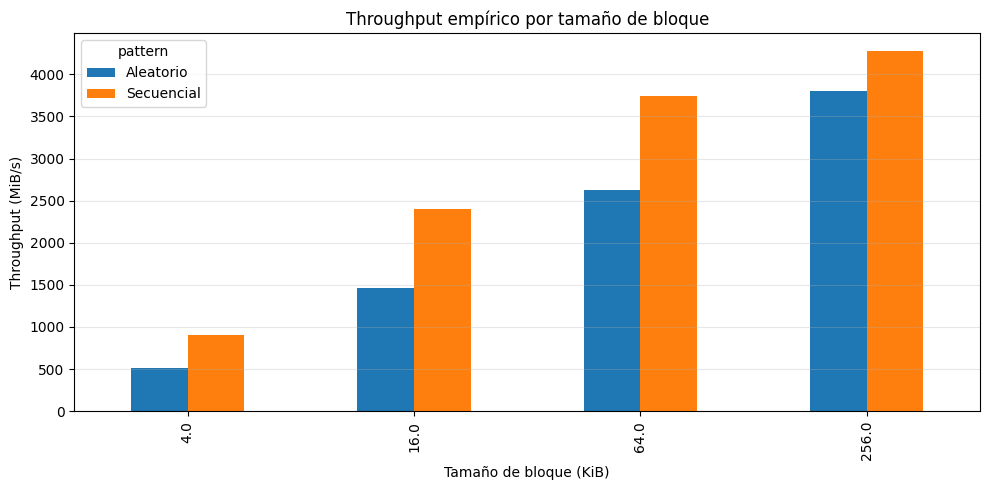

In [18]:
def plot_empirical_throughput(df: pd.DataFrame) -> None:
    """Grafica throughput empírico para secuencial y aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    ax = pivot.plot(kind='bar', figsize=(10, 5))
    ax.set_title('Throughput empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Throughput (MiB/s)')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_throughput.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_throughput.png')
    plt.show()


plot_empirical_throughput(df_empirical)

## Interprete la gráfica de throughput

Describa con sus palabras qué muestra esta gráfica:

- ¿Qué barras son más altas?
- ¿Qué significa eso en términos de rendimiento?
- ¿Cuál patrón aprovecha mejor la lectura en bloques?

> **Criterio mínimo:** mencione al menos un tamaño de bloque específico
> y su valor de throughput observado.

### Respuesta
La gráfica muestra que las barras más altas corresponden al patrón de acceso secuencial, especialmente en los tamaños de bloque más grandes. Por ejemplo, para un tamaño de bloque de 256 KB, el throughput secuencial alcanza aproximadamente 4278 MiB/s, mientras que el aleatorio llega a unos 3800 MiB/s.
Esto significa que el rendimiento es mayor cuando se utilizan bloques más grandes, ya que se aprovecha mejor la capacidad de transferencia del disco y se reduce el impacto de la latencia. A medida que aumenta el tamaño del bloque, el throughput también incrementa tanto en acceso secuencial como aleatorio, aunque el secuencial siempre mantiene mejores resultados.
En conclusión, el patrón que mejor aprovecha la lectura en bloques es el acceso secuencial, porque permite leer datos de forma continua, minimizando interrupciones y logrando mayores velocidades de transferencia.


Guardada: fig_tiempo_empirico.png


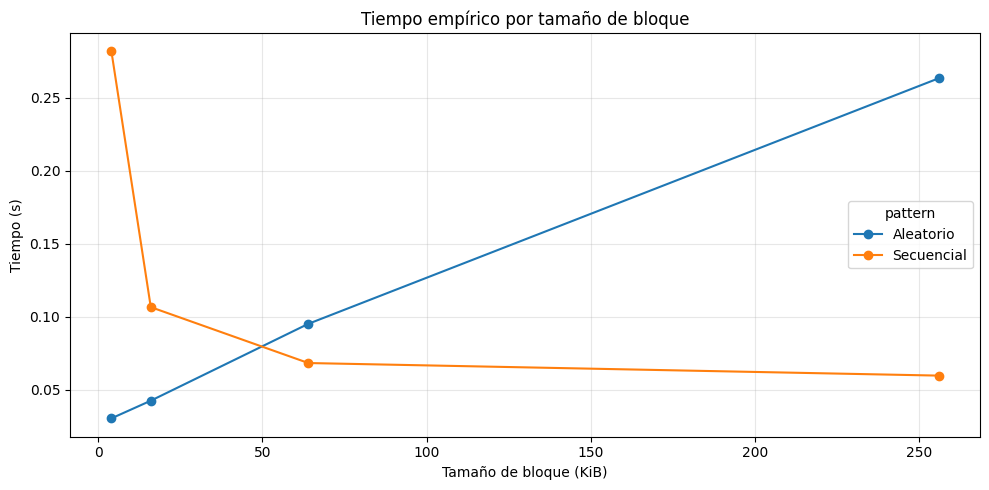

In [19]:
def plot_empirical_time(df: pd.DataFrame) -> None:
    """Grafica tiempo empírico por patrón de acceso."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='elapsed_s'
    ).sort_index()
    ax = pivot.plot(marker='o', figsize=(10, 5))
    ax.set_title('Tiempo empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Tiempo (s)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_tiempo_empirico.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_tiempo_empirico.png')
    plt.show()


plot_empirical_time(df_empirical)

## Interprete la gráfica de tiempo

Explique cómo cambia el tiempo total cuando cambia el tamaño de bloque.

> **Criterio mínimo:** compare el comportamiento de la curva secuencial
> con la aleatorio e indique en qué punto divergen más.

### Respuesta
El tiempo total presenta comportamientos opuestos según el patrón de acceso. En el caso del acceso secuencial, el tiempo disminuye a medida que aumenta el tamaño de bloque: pasa de aproximadamente 0.28 s con 4 KiB a cerca de 0.06 s con 256 KB. Esto ocurre porque al leer bloques más grandes se reduce la cantidad de accesos al disco, aprovechando mejor el throughput.
En contraste, en el acceso aleatorio, el tiempo tiende a aumentar con el tamaño de bloque: desde unos 0.03 s con 4 KiB hasta aproximadamente 0.26 s con 256 KiB. Esto se debe a que cada acceso implica saltos a posiciones distintas del archivo, y al aumentar el tamaño del bloque, cada operación se vuelve más costosa y se transfiere más información por acceso.
Ambas curvas divergen cada vez más a medida que aumenta el tamaño de bloque, siendo la mayor diferencia en 256 KiB, donde el acceso secuencial es mucho más rápido (aproximadamente 0.06 s) que el aleatorio (aproximadamente 0.26 s). Esto evidencia que el acceso secuencial aprovecha mejor los bloques grandes, mientras que el aleatorio pierde eficiencia en ese caso.

Guardada: fig_tiempo_teoria_vs_practica_secuencial.png


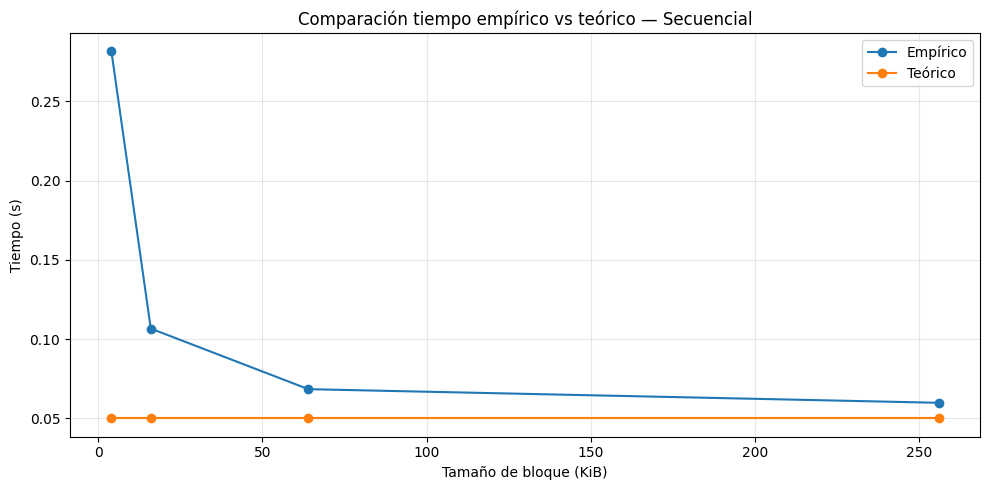

Guardada: fig_tiempo_teoria_vs_practica_aleatorio.png


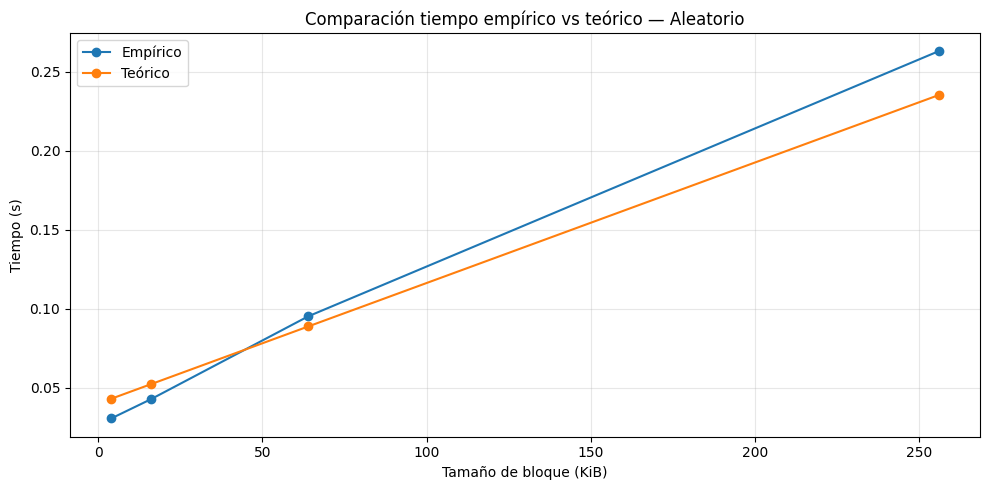

In [20]:
def plot_theory_vs_empirical(df: pd.DataFrame, pattern: str) -> None:
    """Compara tiempo empírico y teórico para un patrón dado."""
    subset = df[df['pattern'] == pattern].sort_values('block_size_kib')
    plt.figure(figsize=(10, 5))
    plt.plot(subset['block_size_kib'], subset['elapsed_s'],
             marker='o', label='Empírico')
    plt.plot(subset['block_size_kib'], subset['theoretical_elapsed_s'],
             marker='o', label='Teórico')
    plt.title(f'Comparación tiempo empírico vs teórico — {pattern}')
    plt.xlabel('Tamaño de bloque (KiB)')
    plt.ylabel('Tiempo (s)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    nombre = f'fig_tiempo_teoria_vs_practica_{pattern.lower()}.png'
    plt.savefig(IMAGES_DIR / nombre, dpi=150, bbox_inches='tight')
    print(f'Guardada: {nombre}')
    plt.show()


plot_theory_vs_empirical(df_compare, 'Secuencial')
plot_theory_vs_empirical(df_compare, 'Aleatorio')

## Interprete la comparación empírico vs teórico

Observe las curvas y responda:

1. ¿Las curvas tienen una tendencia similar?
2. ¿Dónde se separan más?
3. ¿Qué le sugiere eso sobre el modelo usado?

> **Criterio mínimo:** la respuesta 3 debe indicar si el modelo
> sobreestima o subestima el tiempo real, y proponer una razón.

### Respuesta

Las curvas muestran una tendencia parcialmente similar, especialmente en el acceso secuencial, donde ambas se mantienen relativamente estables al aumentar el tamaño de bloque. Sin embargo, no coinciden completamente. En el acceso secuencial, el tiempo empírico disminuye de forma notable al pasar de bloques pequeños a grandes, mientras que el tiempo teórico se mantiene prácticamente constante. Esto indica que, en la práctica, el sistema aprovecha mejor bloques grandes, mientras que el modelo teórico, al asumir un throughput fijo, se representa como una curva casi plana. Además, el tiempo empírico es mayor que el teórico en todos los casos. En el acceso aleatorio, ambas curvas presentan una tendencia creciente en el tiempo de ejecución al aumentar el tamaño de bloque. También, se observa que, el tiempo empírico pasa de ser menor que el teórico a ser mayor a medida que aumenta el tamaño de bloque. Este cambio ocurre aproximadamente en un punto cercano a los 50 KiB el tiempo empírico comienza a superar al teórico. El cruce se da debido a la transición entre el dominio de la latencia y el del throughput. Para bloques pequeños, el tiempo está dominado por la latencia, y en la práctica el sistema puede optimizar estos accesos mediante caché y paralelismo, lo que hace que el tiempo empírico sea menor que el teórico. Sin embargo, a medida que aumenta el tamaño del bloque, el tiempo comienza a estar dominado por el throughput. En este punto, el modelo teórico asume una velocidad de transferencia ideal y constante que no siempre se alcanza en la práctica, por lo que el tiempo empírico termina siendo mayor que el teórico. 
La mayor separación se observa en el acceso secuencial con bloques pequeños, particularmente en 4 KiB, donde el tiempo empírico (0.281671 s) es significativamente mayor que el teórico (0.050010 s). Esta diferencia se debe a que, con bloques pequeños, se realizan muchas más operaciones de lectura, lo que incrementa la latencia acumulada. A medida que el tamaño del bloque aumenta, esta diferencia se reduce, ya que se disminuye el número de accesos y se aprovecha mejor el throughput del dispositivo. En el acceso aleatorio, las curvas están más cercanas, por ejemplo en 64 KiB (0.095255 s vs 0.088828 s), aunque se separan más en tamaños grandes como 256 KiB (0.263121 s vs 0.235313 s).
Esto sugiere que el modelo tiende a subestimar el tiempo real en acceso secuencial (especialmente bloques pequeños), pero en aleatorio pequeño incluso puede sobreestimar. Una posible razón es que el modelo teórico simplifica el sistema a un modelo ideal al no tener en cuenta factores como la latencia adicional introducida por el sistema operativo, la gestión de la caché, la sobrecarga del sistema de archivos y la carga del sistema. Además, estos efectos son más notorios en bloques pequeños, donde el número de operaciones es mayor y se acumulan más costos de acceso, lo que hace que en la práctica los tiempos sean mayores a los estimados.

Guardada: fig_speedup.png


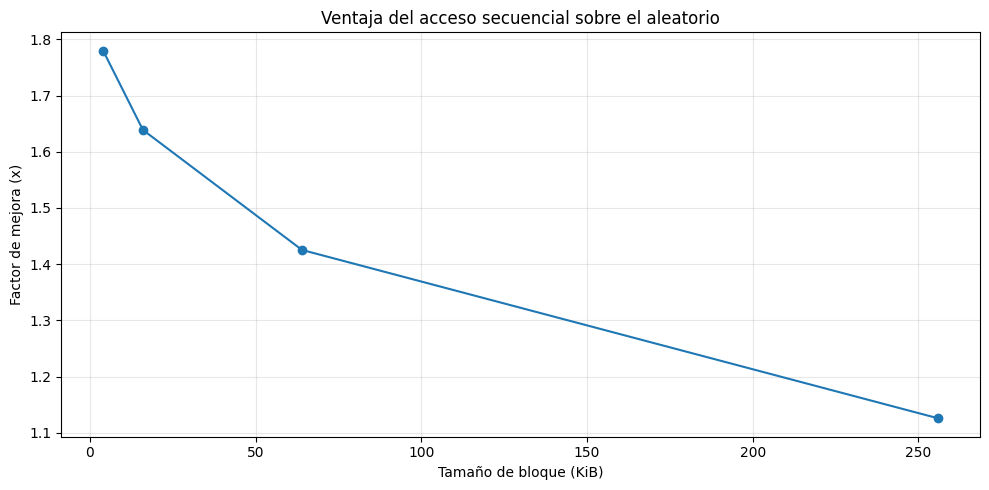

In [21]:
def plot_sequential_speedup(df: pd.DataFrame) -> None:
    """Grafica cuántas veces el acceso secuencial supera al aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    speedup = pivot['Secuencial'] / pivot['Aleatorio']
    ax = speedup.plot(marker='o', figsize=(10, 5))
    ax.set_title('Ventaja del acceso secuencial sobre el aleatorio')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Factor de mejora (x)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_speedup.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_speedup.png')
    plt.show()


plot_sequential_speedup(df_empirical)

## Interprete la ventaja del acceso secuencial

La gráfica muestra cuántas veces el acceso secuencial supera al aleatorio.

- ¿Cuál fue el mayor factor de mejora observado?
- ¿Cómo cambia esa ventaja con el tamaño de bloque?
- ¿Qué implicación tiene esto para el diseño de software?

> **Criterio mínimo:** incluya el valor numérico del mayor speedup
> observado y el tamaño de bloque en que ocurrió.

### Respuesta
La gráfica muestra que el mayor factor de mejora del acceso secuencial sobre el aleatorio se obtiene con bloques de 4 KiB, donde el speedup (factor de mejora) es aproximadamente de 1.78x. Esto indica que, en este caso, el acceso secuencial es significativamente más eficiente que el aleatorio.
A medida que aumenta el tamaño de bloque, esta ventaja disminuye progresivamente. Por ejemplo, en 16 KiB es cercana a 1.64x, en 64 KiB alrededor de 1.42x, y en 256 KiB baja hasta aproximadamente 1.13x. Esto se debe a que, con bloques más grandes, el acceso aleatorio logra aprovechar mejor el throughput, reduciendo la diferencia con el acceso secuencial y el impacto de la latencia.
En términos de diseño de software, esto implica que es fundamental favorecer patrones de acceso secuencial, especialmente cuando se trabajan con bloques pequeños, ya que esto puede mejorar significativamente el rendimiento, teniendo en cuenta que el costo del acceso aleatorio es mucho mayor (latencias, accesos no contiguos, fallos de caché). Sin embargo, al utilizar bloques más grandes, la diferencia entre ambos patrones disminuye, lo que sugiere que optimizar el tamaño de bloque también es una estrategia importante para mejorar la eficiencia del sistema. 

## 10. Resumen automático de resultados

In [22]:
summary_rows = []
for block_size in sorted(df_empirical['block_size_bytes'].unique()):
    seq = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Secuencial')
    ].iloc[0]
    rnd = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Aleatorio')
    ].iloc[0]
    summary_rows.append({
        'block_size_kib': block_size / 1024,
        'seq_time_s': seq['elapsed_s'],
        'rnd_time_s': rnd['elapsed_s'],
        'seq_throughput_mib_s': seq['throughput_mib_s'],
        'rnd_throughput_mib_s': rnd['throughput_mib_s'],
        'seq_vs_rnd_speedup': (
            seq['throughput_mib_s'] / rnd['throughput_mib_s']
            if rnd['throughput_mib_s'] > 0 else np.nan
        ),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary

,block_size_kib,seq_time_s,rnd_time_s,seq_throughput_mib_s,rnd_throughput_mib_s,seq_vs_rnd_speedup
0,4.0,0.281671,0.030599,908.861435,510.632596,1.779874
1,16.0,0.106667,0.042680,2399.988000,1464.372405,1.638919
2,64.0,0.068433,0.095255,3740.896178,2624.545166,1.425350
3,256.0,0.059837,0.263121,4278.267903,3800.535724,1.125701


## Conclusión final

Redacte una conclusión de entre 8 y 12 líneas que integre los
siguientes elementos. Recuerde que esta conclusión también formará
parte de su informe en el `README.md` de entrega.

Su conclusión debe responder, en prosa continua y con sus propias
palabras, las siguientes preguntas:

- ¿Cómo se almacena la información en disco y por qué eso importa?
- ¿Por qué el acceso secuencial y el aleatorio tienen desempeños
  tan distintos, incluso en un SSD?
- ¿Qué tan bien predijo el modelo teórico el comportamiento real
  de su equipo?
- ¿Qué decisión de diseño tomaría en un sistema real con base en
  lo que midió?

> **Criterio mínimo:** la conclusión debe incluir al menos un valor
> numérico concreto de sus resultados (por ejemplo, el factor de
> speedup o el throughput secuencial medido) y conectarlo con uno
> de los conceptos teóricos del curso.

### Conclusión
La información en disco se almacena en bloques físicos de tamaño fijo, organizados en sectores y páginas, que constituyen las unidades mínimas de lectura y escritura del sistema. Esto implica que, aunque se soliciten pocos datos, el sistema debe acceder al bloque completo, por lo que el tamaño de bloque y el patrón de acceso influyen directamente en el rendimiento. En el acceso secuencial, los bloques se encuentran en posiciones contiguas, lo que permite leer grandes cantidades de datos en una operación continua, aprovechando al máximo el throughput del dispositivo y reduciendo la cantidad de veces que se incurre en latencia de acceso.
En contraste, en el acceso aleatorio, cada lectura se realiza sobre ubicaciones dispersas, lo que obliga al sistema a ejecutar múltiples operaciones independientes. Aunque los SSD no 
tienen parte móviles, por lo que no existe tiempo de seek ni latencia rotacional, sí se debe tener en cuenta una latencia de acceso del controlador (AccessLatency) que se paga en cada operación. Cuando se realizan muchos accesos pequeños, esta latencia se acumula y reduce significativamente el rendimiento. Adicionalmente, el controlador del SSD puede convertirse en un cuello de botella al manejar múltiples solicitudes dispersas, lo que limita el desempeño. Si bien fenómenos como la granularidad de escritura y el write amplification afectan principalmente las escrituras, también evidencian cómo la organización interna del SSD introduce costos adicionales en accesos no contiguos.
Los resultados obtenidos reflejan claramente esta diferencia: el acceso secuencial fue consistentemente más eficiente, alcanzando un throughput de 4278.267903 MiB/s en bloques de 256 KB, mientras que el acceso aleatorio presentó un menor rendimiento. Además, el mayor speedup se observó en bloques de 4 KB, con un valor de 1.779874x, lo que evidencia que la latencia tiene un mayor impacto cuando se realizan muchos accesos pequeños, ya que el número de operaciones aumenta y el costo de acceso se acumula
En cuanto al modelo teórico, este logró capturar la tendencia general del comportamiento, pero no coincidió completamente con los valores empíricos. En particular, tendió a subestimar el tiempo real en acceso secuencial y mostró variaciones en acceso aleatorio, debido a que no considera factores como la caché del sistema operativo, la sobrecarga del sistema de archivos, la carga del sistema y características internas del hardware.
Con base en estos resultados, en un sistema real se tomaría la decisión de favorecer patrones de acceso secuencial y trabajar con bloques de mayor tamaño, ya que esto reduce el número de accesos y permite aprovechar mejor el throughput. Además, de que al agrupar las operaciones de lectura y escritura en bloques grandes y contiguos, se minimiza el costo del acceso aleatorio, se aprovecha el hardware y mejora la eficiencia general del sistema.

## 11. Preguntas de cierre

Responda en el `README.md` de su repositorio de entrega, apoyándose
en los resultados del experimento.

1. **Comparación de patrones:** Con base en sus mediciones, ¿cuántas
   veces más rápido fue el acceso secuencial respecto al aleatorio en
   su equipo? ¿Ese resultado era el esperado según la teoría?

2. **Efecto del tamaño de bloque:** ¿Qué ocurrió con el throughput del
   acceso aleatorio a medida que aumentó el tamaño de bloque?
   ¿Por qué cree que sucede eso?

3. **Teoría vs práctica:** Identifique un caso en sus resultados donde
   la medición empírica se alejó del modelo teórico. ¿A qué factor
   atribuye esa diferencia?

4. **Tipo de disco:** Compare sus resultados con los valores de referencia
   de la tabla de la guía. ¿Su equipo se comportó como un HDD, un SSD
   SATA o un SSD NVMe?

5. **Aplicación práctica:** Imagine que debe almacenar una tabla de
   estudiantes con 1 millón de registros. Con base en lo que midió,
   ¿preferiría leerla toda de forma secuencial o acceder a registros
   individuales de forma aleatoria? ¿Por qué?

## 12. Extensiones sugeridas

Si desea profundizar, puede ampliar el experimento de las siguientes formas:

- Repetir el experimento varias veces y promediar los resultados.
- Comparar lectura y escritura.
- Medir sobre SSD local vs disco de red.
- Cambiar el tamaño del archivo y observar el efecto en la caché.
- Comparar caché caliente vs caché fría ejecutando el benchmark dos veces seguidas.